# Access the analysis ready ORAS5 data

This notebook provides an example of how to open the reanalysis-oras5 Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds-dev-cci2.copernicus-climate.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds-dev-cci2.copernicus-climate.eu/datasets/how-to-use-the-dss-arco-dataset).

In [ ]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDSAPI key in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDSAPI key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")


## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [2]:
import xarray as xr

# Time-chunked data for access optimised across spatial dimensions (e.g. a global map plot for a single time-step)
timechunked_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-001/arco/reanalysis_oras5/consolidated/timeChunked.zarr"
timechunked_operational_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-001/arco/reanalysis_oras5/operational/timeChunked.zarr"

# Geochunked data for access optimised across time dimension (e.g. a time-series plot for a single location)
geochunked_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-001/arco/reanalysis_oras5/consolidated/geoChunked.zarr"
geochunked_operational_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-001/arco/reanalysis_oras5/operational/geoChunked.zarr"

# Open the geochunked_consolidated_url with xarray
ds = xr.open_zarr(
    geochunked_consolidated_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 253GB
Dimensions:    (time: 684, elevation: 75, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 5kB 1958-01-01 1958-02-01 ... 2014-12-01
  * elevation  (elevation) float32 300B -5.902e+03 -5.698e+03 ... -1.556 -0.5058
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables: (12/15)
    vosaline   (time, elevation, latitude, longitude) float32 213GB dask.array<chunksize=(264, 1, 64, 64), meta=np.ndarray>
    iicethic   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    iicevelu   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    iicevelv   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    ileadfra   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    so20chgt   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    ...         ...
    somxl010   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    somxl030   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    sosaline   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    sossheig   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    sosstsst   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    sozotaux   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>

Extract a point and plot a time-series using earthkit-plots

/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/ipykernel_78149/4232155238.py:13: UserWarning: TimeSeries is an experimental new feature in earthkit-plots. We welcome feedback and bug reports on GitHub issues: https://github.com/ecmwf/earthkit-plots/issues
  chart = ekp.TimeSeries()
/opt/homebrew/Caskroom/miniforge/base/envs/CDS/lib/python3.12/site-packages/earthkit/plots/components/subplots.py:1213: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax.legend(*args, **kwargs)


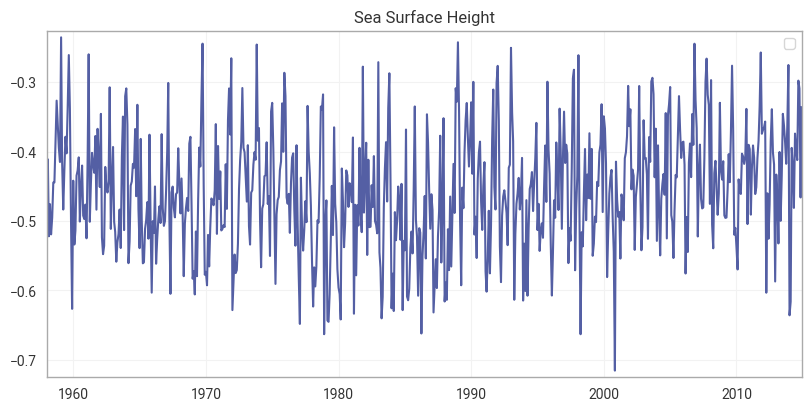

In [ ]:
from earthkit import plots as ekp

# select variable to plot (Sea Surface Temperature)
variable_name = "sossheig"
# select a point to plot (Dogger Bay in the North Sea)
location = {
    "latitude": 55.0,
    "longitude": 2.0
}
plot_data = ds[variable_name].sel(latitude=location["latitude"], longitude=location["longitude"], method="nearest")

chart = ekp.TimeSeries()

chart.line(plot_data)

chart.title("{variable_name}")
chart.legend()

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [4]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Time-chunked data for access optimised across spatial dimensions (e.g. a global map plot for a single time-step)
timechunked_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-001/arco/reanalysis_oras5/consolidated/timeChunked.zarr"
timechunked_operational_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-001/arco/reanalysis_oras5/operational/timeChunked.zarr"

# Geochunked data for access optimised across time dimension (e.g. a time-series plot for a single location)
geochunked_consolidated_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-001/arco/reanalysis_oras5/consolidated/geoChunked.zarr"
geochunked_operational_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-001/arco/reanalysis_oras5/operational/geoChunked.zarr"

# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_consolidated_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds

<xarray.Dataset> Size: 253GB
Dimensions:    (time: 684, elevation: 75, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 5kB 1958-01-01 1958-02-01 ... 2014-12-01
  * elevation  (elevation) float32 300B -5.902e+03 -5.698e+03 ... -1.556 -0.5058
  * latitude   (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables: (12/15)
    vosaline   (time, elevation, latitude, longitude) float32 213GB dask.array<chunksize=(264, 1, 64, 64), meta=np.ndarray>
    iicethic   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    iicevelu   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    iicevelv   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    ileadfra   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    so20chgt   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    ...         ...
    somxl010   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    somxl030   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    sosaline   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    sossheig   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    sosstsst   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    sozotaux   (time, latitude, longitude) float32 3GB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.